In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import ray
from ray import serve

In [100]:
import cv2
from utils.gui import vis, vbbox
orig = cv2.imread(f"/home/petr/study/diploma/src/datasetgen/demo/044030790.png")


p1=(31, 71) p2=(44, 79)
p1=(47, 53) p2=(138, 61)
p1=(200, 54) p2=(272, 61)
p1=(46, 71) p2=(270, 79)
p1=(47, 88) p2=(104, 98)
p1=(553, 49) p2=(803, 61)
p1=(929, 25) p2=(1020, 33)
p1=(1083, 26) p2=(1155, 33)
p1=(911, 44) p2=(1152, 52)
p1=(928, 63) p2=(986, 72)
p1=(1159, 79) p2=(1251, 90)
p1=(29, 138) p2=(117, 146)
p1=(186, 138) p2=(276, 148)
p1=(373, 138) p2=(463, 148)
p1=(836, 138) p2=(922, 148)
p1=(1055, 138) p2=(1146, 148)
p1=(51, 165) p2=(139, 173)
p1=(55, 182) p2=(135, 191)
p1=(69, 199) p2=(121, 211)
p1=(188, 165) p2=(304, 174)
p1=(183, 183) p2=(306, 191)
p1=(218, 201) p2=(272, 211)
p1=(354, 169) p2=(490, 177)
p1=(350, 185) p2=(493, 193)
p1=(361, 204) p2=(481, 212)
p1=(389, 221) p2=(453, 229)
p1=(883, 167) p2=(960, 175)
p1=(873, 188) p2=(968, 196)
p1=(890, 205) p2=(951, 213)
p1=(1090, 167) p2=(1147, 175)
p1=(1063, 187) p2=(1175, 196)
p1=(1002, 213) p2=(1039, 222)
p1=(60, 248) p2=(122, 257)
p1=(193, 248) p2=(256, 257)
p1=(938, 248) p2=(971, 256)
p1=(395, 269) p2=(468, 278)
p1=(123, 2

(ServeReplica:default:OCRReaderYandex pid=156291) INFO 2026-03-09 19:42:00,638 default_OCRReaderYandex rhef0ihm 8dfb2583-471e-42d0-b528-4511522028c2 -- CALL __call__ OK 1902.8ms


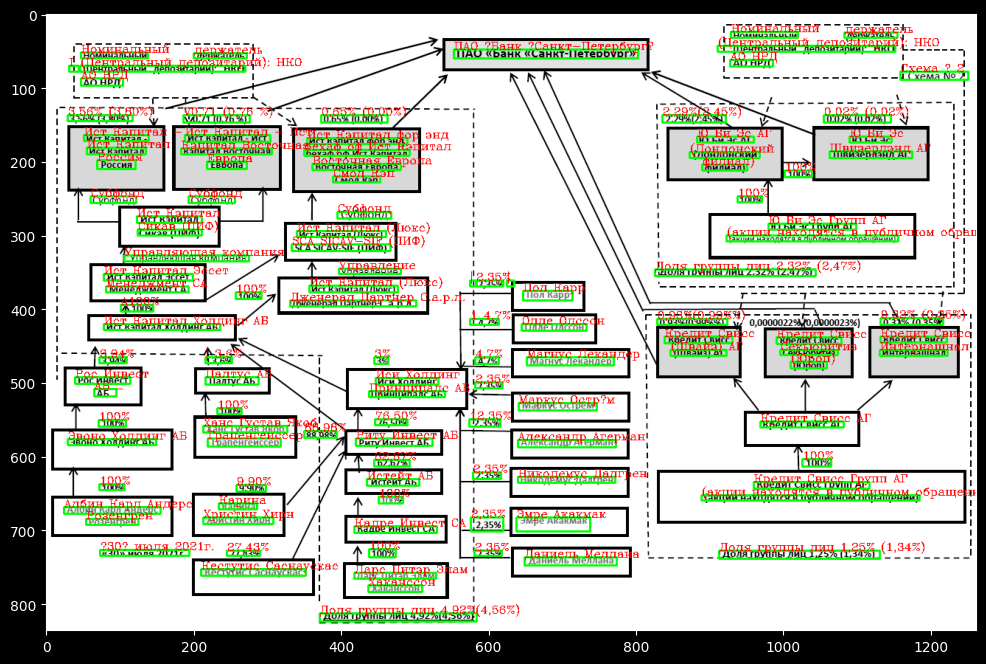

In [111]:
# ocr = serve.get_deployment_handle("OCRReaderYandex", app_name="default")
ocr = serve.get_deployment_handle("OCRReaderEasyocr", app_name="default")

res = await ocr.remote(orig)
res_b, res_t = res.boxes

vis(vbbox(orig, res_b, res_t))

In [7]:
dge = serve.get_deployment_handle("DiagramGraphExtractor", app_name="default")

INFO 2026-03-09 19:02:59,721 serve 142974 -- Started <ray.serve._private.router.SharedRouterLongPollClient object at 0x7f3d5a744410>.
(ServeReplica:default:DiagramGraphExtractor pid=142785) INFO 2026-03-09 19:03:00,681 default_DiagramGraphExtractor xa730rbf de92ec11-6dcd-4a03-b3d4-257dc7fdc37b -- CALL __call__ OK 928.4ms


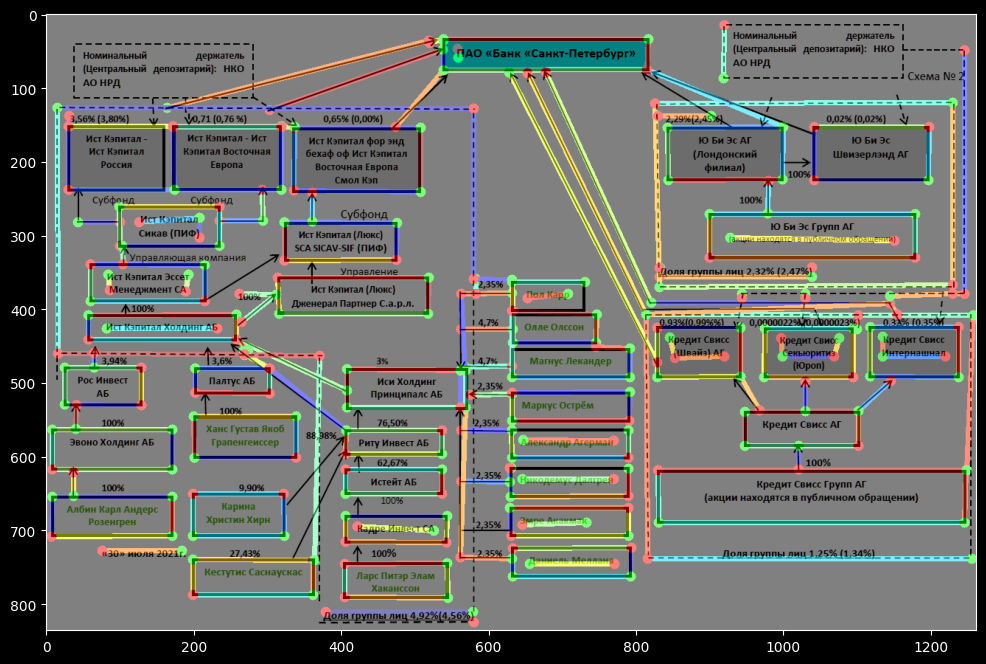

In [8]:
im_dg = await dge.remote(orig)
out = cv2.addWeighted(orig, 0.5, im_dg, 0.5,0)
vis(out)

(ServeReplica:default:DiagramNodesDetector pid=153648) [YOLO-DIAG] Running
(ServeReplica:default:DiagramNodesDetector pid=153648) 
(ServeReplica:default:DiagramNodesDetector pid=153648) 0: 448x640 39 nodes, 43 arrowheads, 192.8ms
(ServeReplica:default:DiagramNodesDetector pid=153648) Speed: 1.4ms preprocess, 192.8ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)
(ServeReplica:default:DiagramNodesDetector pid=153648) [YOLO-DIAG] Detections: dict_items([(NODE, 39), (ARROWHEAD, 37)])


(ServeReplica:default:DiagramNodesDetector pid=153648) INFO 2026-03-09 19:35:39,347 default_DiagramNodesDetector bz48z1cf 1b638db6-9c14-4607-9202-57cb06858313 -- CALL __call__ OK 198.1ms


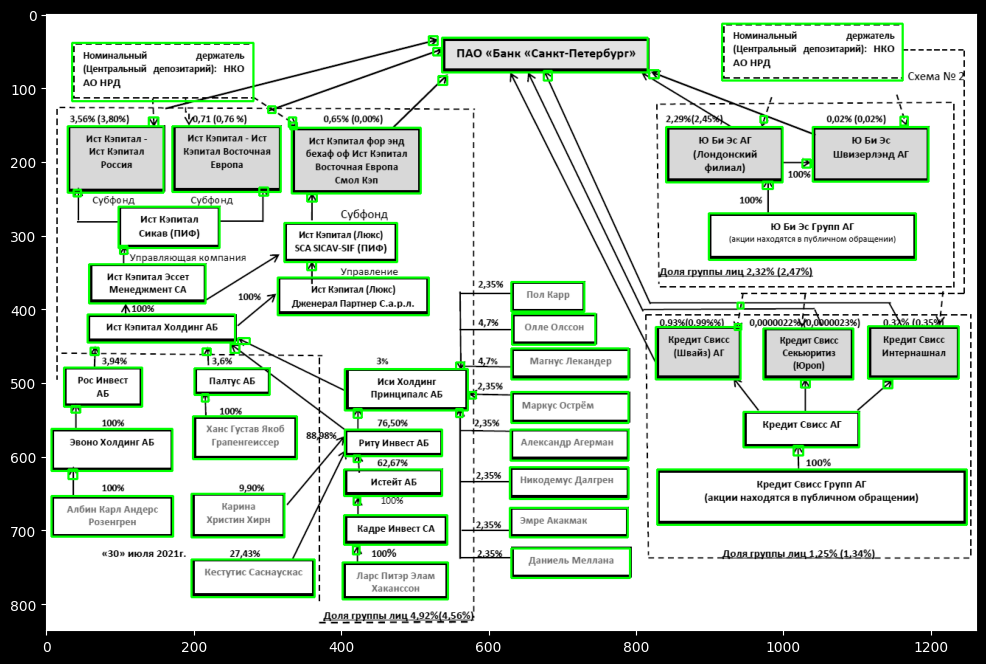

In [93]:
from visual.analyze.detection.main import DiagramNodesDetector

dnd = serve.get_deployment_handle("DiagramNodesDetector", app_name="default")
bbs = await dnd.remote(orig)

# bbs = DiagramNodesDetector(config=dict(conf=0.1, iou=0.4, imgsz=1280))(orig)
bbs = [i.bbox for i in bbs]

vis(vbbox(orig, bbs))